In [6]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

df = pd.read_csv('Heart_Disease_Prediction.csv')

# Display first 5 rows

df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [7]:
# Dataset shape

print("Dataset Shape:", df.shape)

# Column names

print("\nColumns:\n", df.columns)

# Data types

print("\nData Types:\n")
print(df.dtypes)

# Missing values

print("\nMissing Values:\n")
print(df.isnull().sum())

# Duplicate rows

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (270, 14)

Columns:
 Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

Data Types:

Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object

Missing Values:

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG resu

In [8]:
# Convert target column into numeric values

df['Heart Disease'] = df['Heart Disease'].map({
    'Presence': 1,
    'Absence': 0
})

# Check updated values

print(df['Heart Disease'].head())

0    1
1    0
2    1
3    0
4    0
Name: Heart Disease, dtype: int64


In [9]:
# Features (Input)

X = df.drop('Heart Disease', axis=1)

# Target (Output)

y = df['Heart Disease']

# Display shapes

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (270, 13)
y Shape: (270,)


In [10]:
# Import train_test_split

from sklearn.model_selection import train_test_split

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Print shapes

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (216, 13)
X_test: (54, 13)
y_train: (216,)
y_test: (54,)


In [11]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create model

log_model = LogisticRegression(max_iter=1000)

# Train model

log_model.fit(X_train, y_train)

# Make predictions

y_pred_log = log_model.predict(X_test)

# Display predictions

print(y_pred_log[:10])

[1 1 0 0 0 1 1 0 0 0]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
# Import accuracy score

from sklearn.metrics import accuracy_score

# Calculate accuracy

log_accuracy = accuracy_score(y_test, y_pred_log)

# Print accuracy

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.9259259259259259


In [13]:
# Import confusion matrix

from sklearn.metrics import confusion_matrix

# Create confusion matrix

cm = confusion_matrix(y_test, y_pred_log)

print(cm)

[[32  1]
 [ 3 18]]


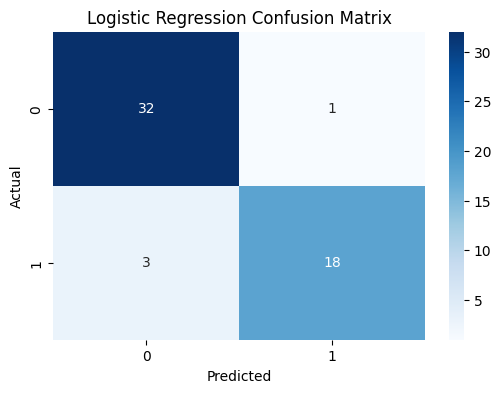

In [14]:
# Plot confusion matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Logistic Regression Observation

The Logistic Regression model achieved approximately 92.59% accuracy. The confusion matrix shows that the model correctly predicted most heart disease cases with very few incorrect classifications.

In [7]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('Heart_Disease_Prediction.csv')

# Convert target column to numeric
df['Heart Disease'] = df['Heart Disease'].map({
    'Presence': 1,
    'Absence': 0
})

# Features and target
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Dataset Loaded Successfully")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Dataset Loaded Successfully
X_train: (216, 13)
X_test: (54, 13)


In [9]:
# Import KNN and metrics

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Create KNN model

knn_model = KNeighborsClassifier(n_neighbors=5)

# Train model

knn_model.fit(X_train, y_train)

# Predictions

y_pred_knn = knn_model.predict(X_test)

# Accuracy

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

# Confusion Matrix

cm_knn = confusion_matrix(y_test, y_pred_knn)

print("\nConfusion Matrix:")
print(cm_knn)

KNN Accuracy: 0.6481481481481481

Confusion Matrix:
[[22 11]
 [ 8 13]]


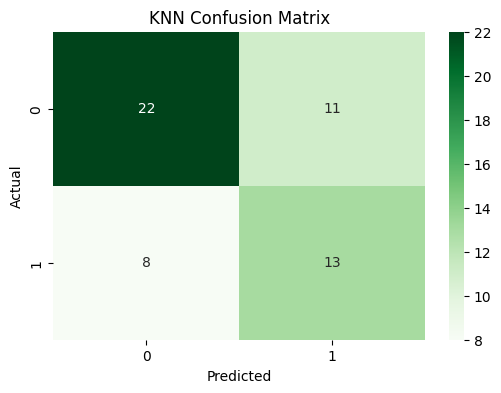

In [10]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### KNN Observation

The K-Nearest Neighbors model achieved an accuracy of approximately 64.81%, which is significantly lower than Logistic Regression. The confusion matrix shows a higher number of misclassifications, indicating that KNN is less suitable for this dataset.

In [11]:
# Import Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Create model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model

rf_model.fit(X_train, y_train)

# Predictions

y_pred_rf = rf_model.predict(X_test)

# Accuracy

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

# Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\nConfusion Matrix:")
print(cm_rf)

Random Forest Accuracy: 0.7962962962962963

Confusion Matrix:
[[29  4]
 [ 7 14]]


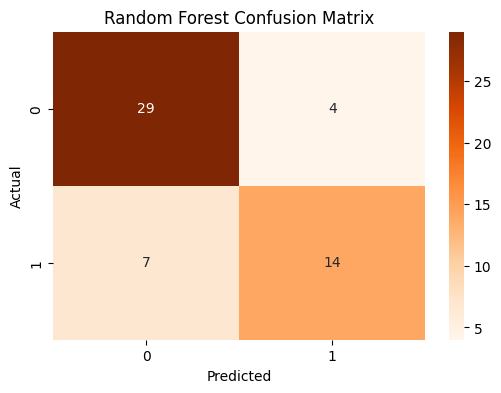

In [12]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Random Forest Observation

The Random Forest model achieved an accuracy of approximately 79.63% in predicting heart disease. The confusion matrix indicates that the model correctly classified most patients, but it produced more misclassifications compared to Logistic Regression. Although Random Forest performed better than KNN, it was not the best-performing model for this dataset.

In [14]:
# Model Comparison

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Random Forest'
    ],
    'Accuracy': [
        0.9259,
        0.6481,
        0.7963
    ]
})

comparison = comparison.sort_values(
    by='Accuracy',
    ascending=False
)

print(comparison)

                 Model  Accuracy
0  Logistic Regression    0.9259
2        Random Forest    0.7963
1                  KNN    0.6481


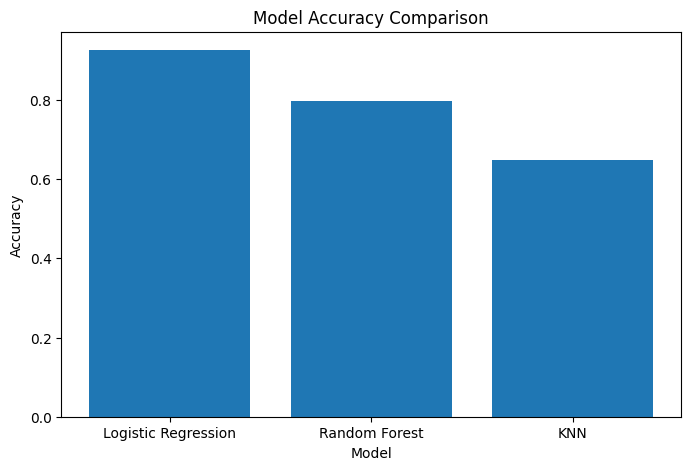

In [15]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['Accuracy']
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')

plt.show()

### Model Comparison Observation

Among all three machine learning algorithms, Logistic Regression achieved the highest accuracy of 92.59%, followed by Random Forest at 79.63% and KNN at 64.81%. Therefore, Logistic Regression was selected as the best-performing model for heart disease prediction in this project.

# Best Model Selection

Based on the evaluation results, Logistic Regression was selected as the best model because it achieved the highest accuracy and produced the fewest classification errors. The model demonstrated strong predictive performance for identifying the presence or absence of heart disease.
### Why Logistic Regression Performed Better

The Heart Disease dataset contains relatively few records (270 samples) and exhibits relationships that can be effectively modeled using Logistic Regression. Because of the dataset's size and characteristics, Logistic Regression generalized better and achieved higher accuracy than both KNN and Random Forest.

# Conclusion

This project developed and evaluated multiple machine learning models for heart disease prediction using patient medical data. Data preprocessing, feature selection, train-test splitting, model training, and evaluation were performed successfully.

Three machine learning algorithms were compared:
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Random Forest

Among these models, Logistic Regression achieved the highest accuracy of 92.59% and was selected as the best-performing model. The results demonstrate that machine learning can effectively assist in predicting heart disease using clinical patient information.